# Homework 2: Exploratory Data Analysis

## International Coastal Cleanup Dataset

This notebook explores the International Coastal Cleanup dataset provided through the Norfolk OpenData Portal. The goal of this exploratory data analysis (EDA) is to understand the structure and characteristics of the dataset and identify important patterns in the data.

The analysis examines the size of the dataset, data types, missing values, descriptive statistics, distributions, possible outliers, and relationships among variables.

In [1]:
# load in the packages needed for the analysis

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


In [2]:
# load in the International Coastal Cleanup dataset

infile = '/Users/mitra/OEAS805/data/International_Coastal_Cleanup.csv'
# read in the .csv file with the column separator explicitly defined
data = pd.read_csv(infile, sep = ',' , low_memory = False)

In [3]:
# the shape of the data
# nrows, ncols
data.shape

(77, 53)

In [4]:
# total number of datapoints in the dataframe
# ncol * nrows
data.size 

4081

  #### Size of the Dataset

The dataset contains 77 rows (data points) and 53 variables (columns), with 4,081 total data values.

In [5]:
# print the information about the data in the dataframe
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 53 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Area                                       77 non-null     str    
 1   Date                                       77 non-null     str    
 2   Cigarette Butts                            77 non-null     str    
 3   Food Wrappers (candy, chips, etc.)         77 non-null     str    
 4   Take Out/Away Containers (Plastic)         77 non-null     int64  
 5   Take Out/Away Containers (Foam)            77 non-null     int64  
 6   Bottle Caps (Plastic)                      77 non-null     int64  
 7   Bottle Caps (Metal)                        77 non-null     str    
 8   Lids (Plastic)                             77 non-null     int64  
 9   Straws, Stirrers                           77 non-null     int64  
 10  Forks, Knives, Spoons                  

#### Data Types
The dataset contains a combination of data types. Some variables are strings (str), while the numerical variables include integers (int64) and floating-point numbers (float64). Therefore, not all variables have the same data type.

In [6]:
# Check for missing data
data.isnull().sum()

Area                                         0
Date                                         0
Cigarette Butts                              0
Food Wrappers (candy, chips, etc.)           0
Take Out/Away Containers (Plastic)           0
Take Out/Away Containers (Foam)              0
Bottle Caps (Plastic)                        0
Bottle Caps (Metal)                          0
Lids (Plastic)                               0
Straws, Stirrers                             0
Forks, Knives, Spoons                        0
Beverage Bottles (Plastic)                   0
Beverage Bottles (Glass)                     0
Beverage Cans                                0
Grocery Bags (Plastic)                       0
Other Plastic Bags                           0
Paper Bags                                   0
Cups, Plates (Paper)                         0
Cups, Plates (Plastic)                       0
Cups, Plates (Foam)                          0
Fishing Buoys, Pots & Traps                  0
Fishing Net &

#### Missing Data
The dataset doesnot contain any missing values. All 53 variables have zero missing data points.

In [7]:
# descriptive statistics for the numeric data in the dataframe
data.describe()

,Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Lids (Plastic),"Straws, Stirrers","Forks, Knives, Spoons",Beverage Bottles (Plastic),Beverage Cans,Grocery Bags (Plastic),Other Plastic Bags,...,Toys,Other Trash (Clean Swell),Condoms,Diapers,Syringes,Tampons/Tampon Applicators,Foam Pieces,Number of Volunteers,Volunteer Hours,Number of Miles
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,...,77.000000,77.000000,77.000000,77.000000,77.00000,77.000000,77.000000,77.000000,77.00000,77.000000
mean,18.363636,13.714286,98.337662,23.350649,50.558442,13.909091,68.922078,44.350649,38.961039,36.233766,...,0.168831,18.961039,1.909091,1.259740,0.61039,0.922078,64.441558,18.896104,37.37013,1.530909
std,21.944253,18.943724,148.793093,26.738877,62.141920,20.238825,92.227089,55.825331,59.709922,77.109269,...,0.864544,67.232989,4.205829,3.743073,1.94771,2.113654,128.515767,27.249135,57.04352,1.486711
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,1.000000,16.000000,6.000000,11.000000,1.000000,15.000000,6.000000,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,5.000000,9.00000,1.000000
50%,8.000000,6.000000,43.000000,13.000000,24.000000,7.000000,34.000000,26.000000,17.000000,10.000000,...,0.000000,0.000000,1.000000,0.000000,0.00000,0.000000,14.000000,11.000000,22.00000,1.000000
75%,31.000000,19.000000,107.000000,33.000000,72.000000,20.000000,70.000000,67.000000,44.000000,34.000000,...,0.000000,1.000000,2.000000,1.000000,1.00000,1.000000,58.000000,22.000000,38.00000,2.000000
max,90.000000,106.000000,780.000000,109.000000,368.000000,136.000000,395.000000,276.000000,326.000000,542.000000,...,7.000000,441.000000,33.000000,24.000000,15.00000,14.000000,750.000000,178.000000,396.00000,10.000000


#### Descriptive Statistics
The descriptive statistics show the count, mean, standard deviation, minimum, median, quartiles, and maximum for the numeric variables. For several variables, the mean is higher than the median and the maximum value is much higher than the median. This suggests that some variables may have skewed distributions or high values. I will explore these patterns further using plots

#### Distribution of the Data

To better understand the distribution of the data, I looked at the Number of Volunteers variable using a histogram.

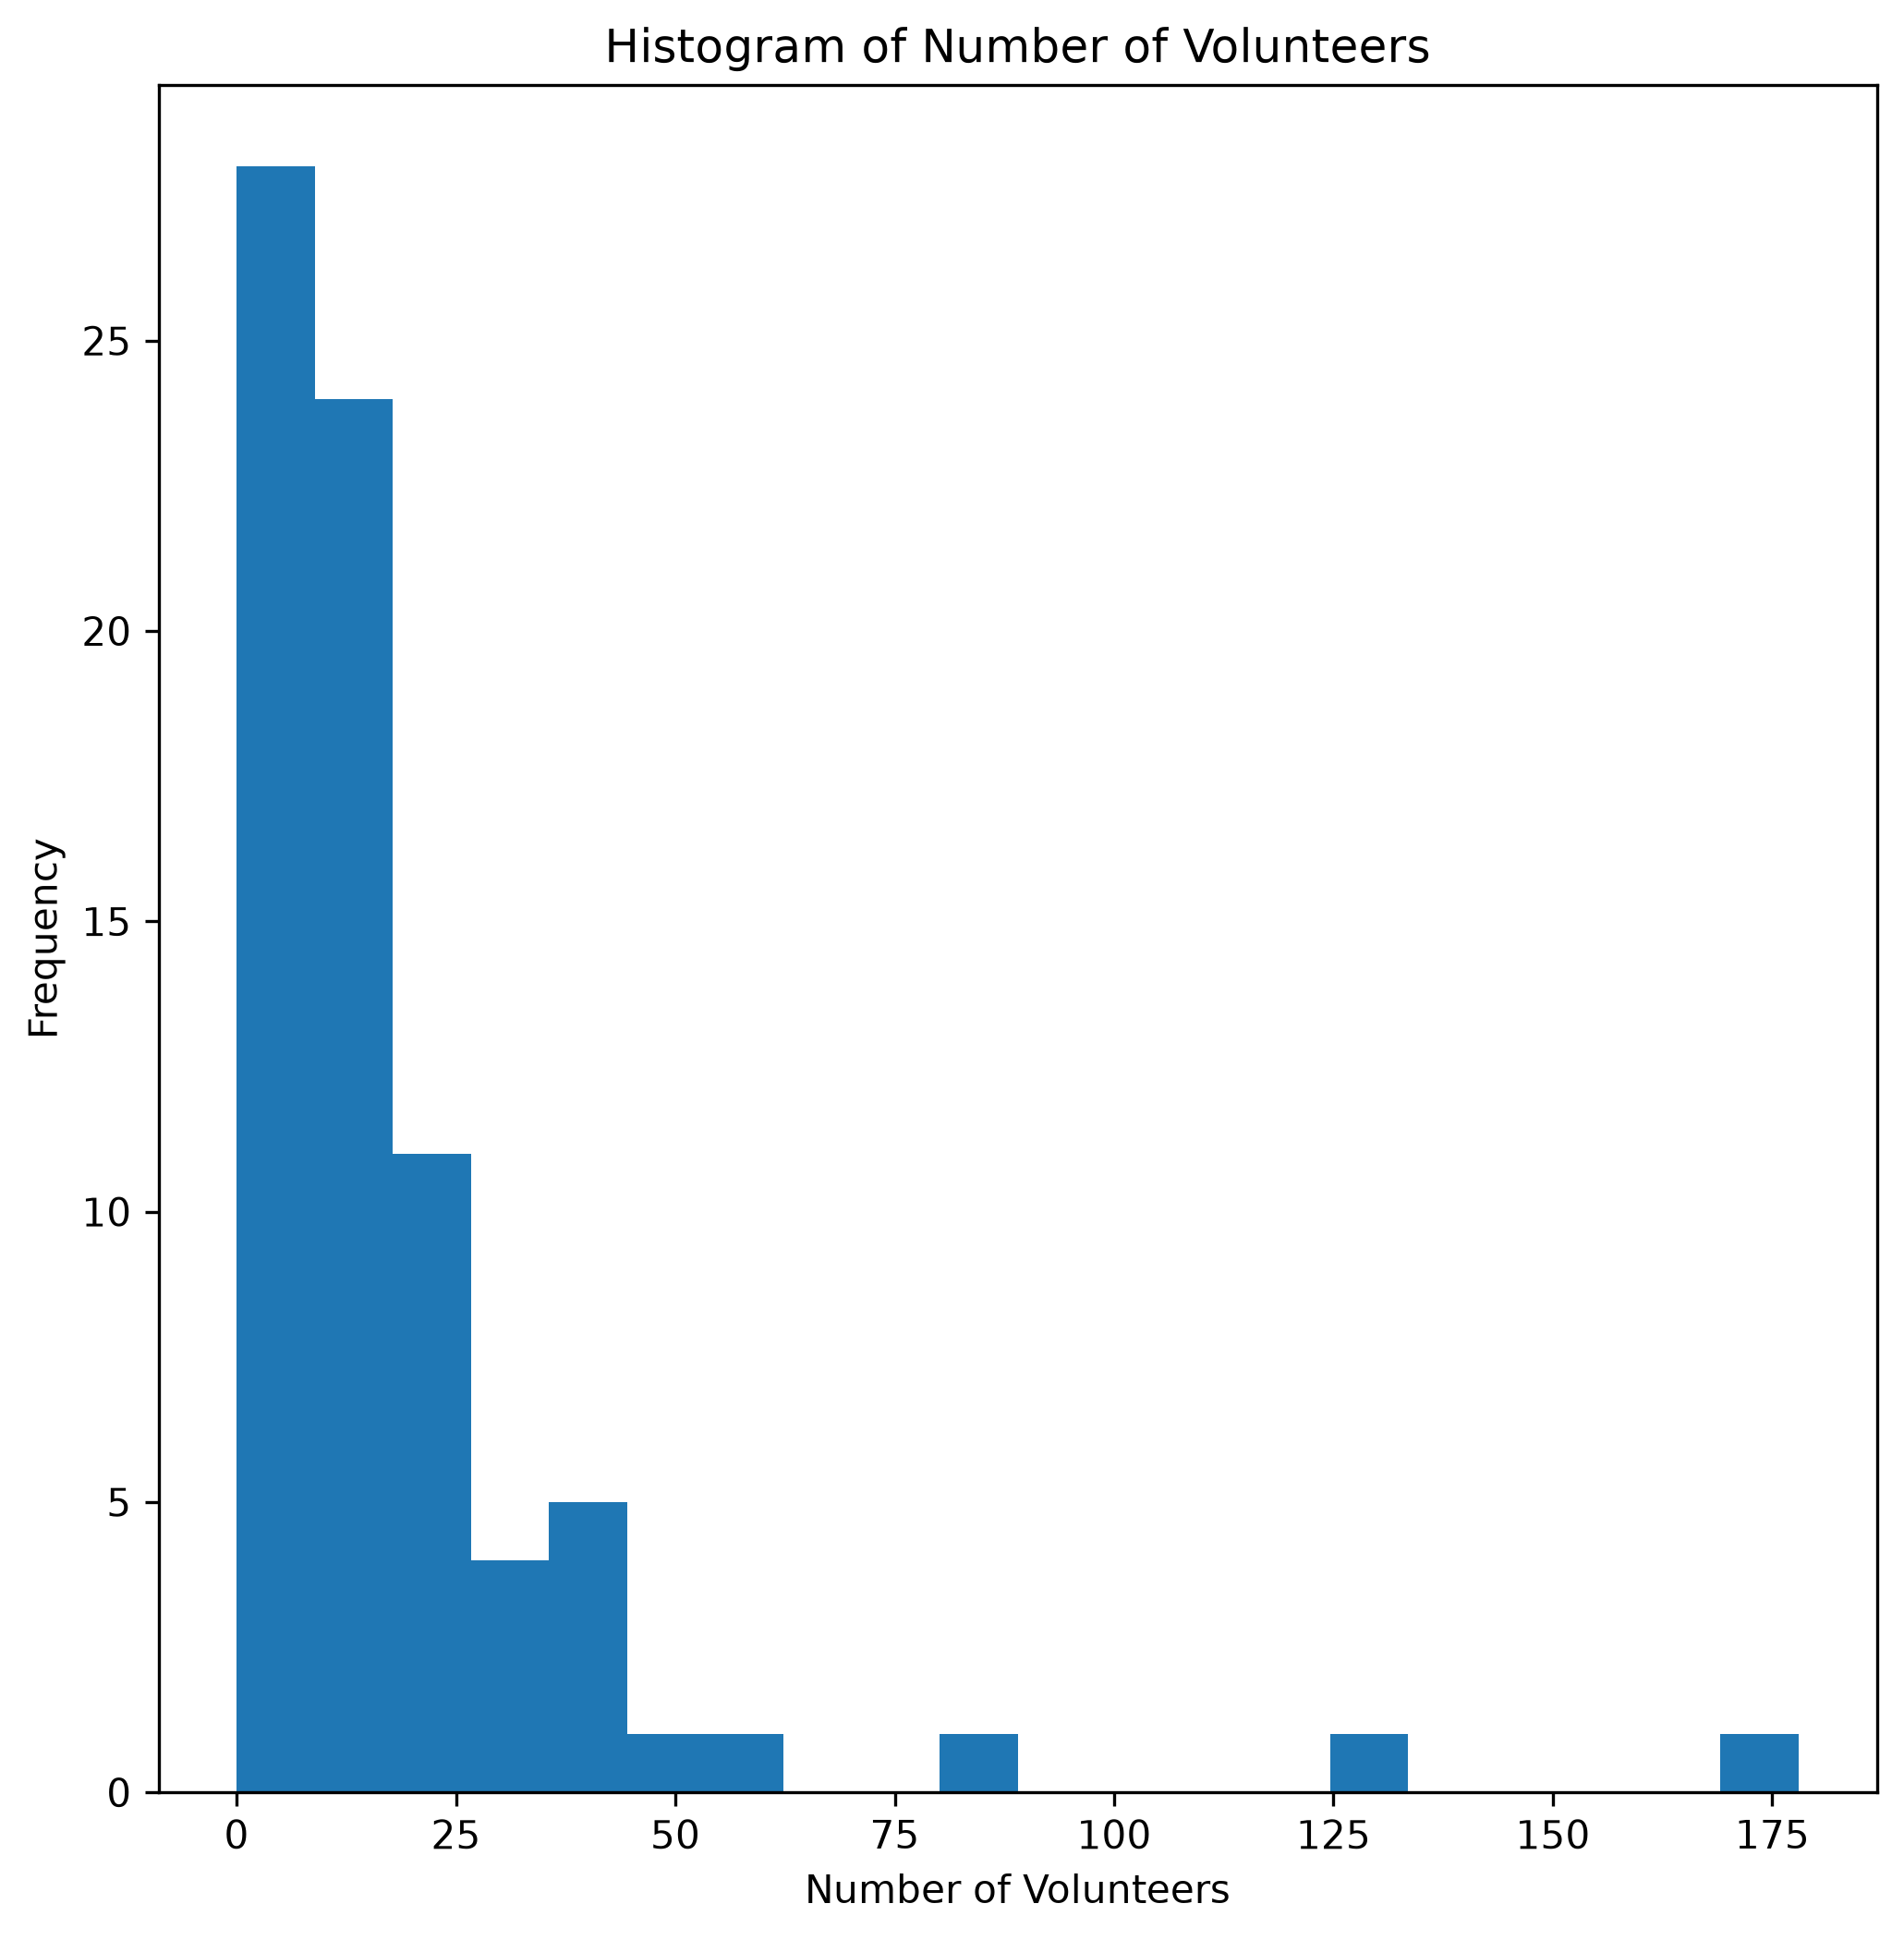

In [8]:
# histogram of Number of Volunteers
fig, ax = plt.subplots(1, figsize=(8,8), dpi=300)
plt.hist(data['Number of Volunteers'].dropna(), bins=20)
plt.title("Histogram of Number of Volunteers")
plt.xlabel("Number of Volunteers")
plt.ylabel("Frequency")
plt.show()

#### Histogram Interpretation: 
The number of volunteers is concentrated at lower values, while only a few observations have a large number of volunteers. The distribution is right-skewed, with a few unusually high values.

<Axes: ylabel='Number of Volunteers'>

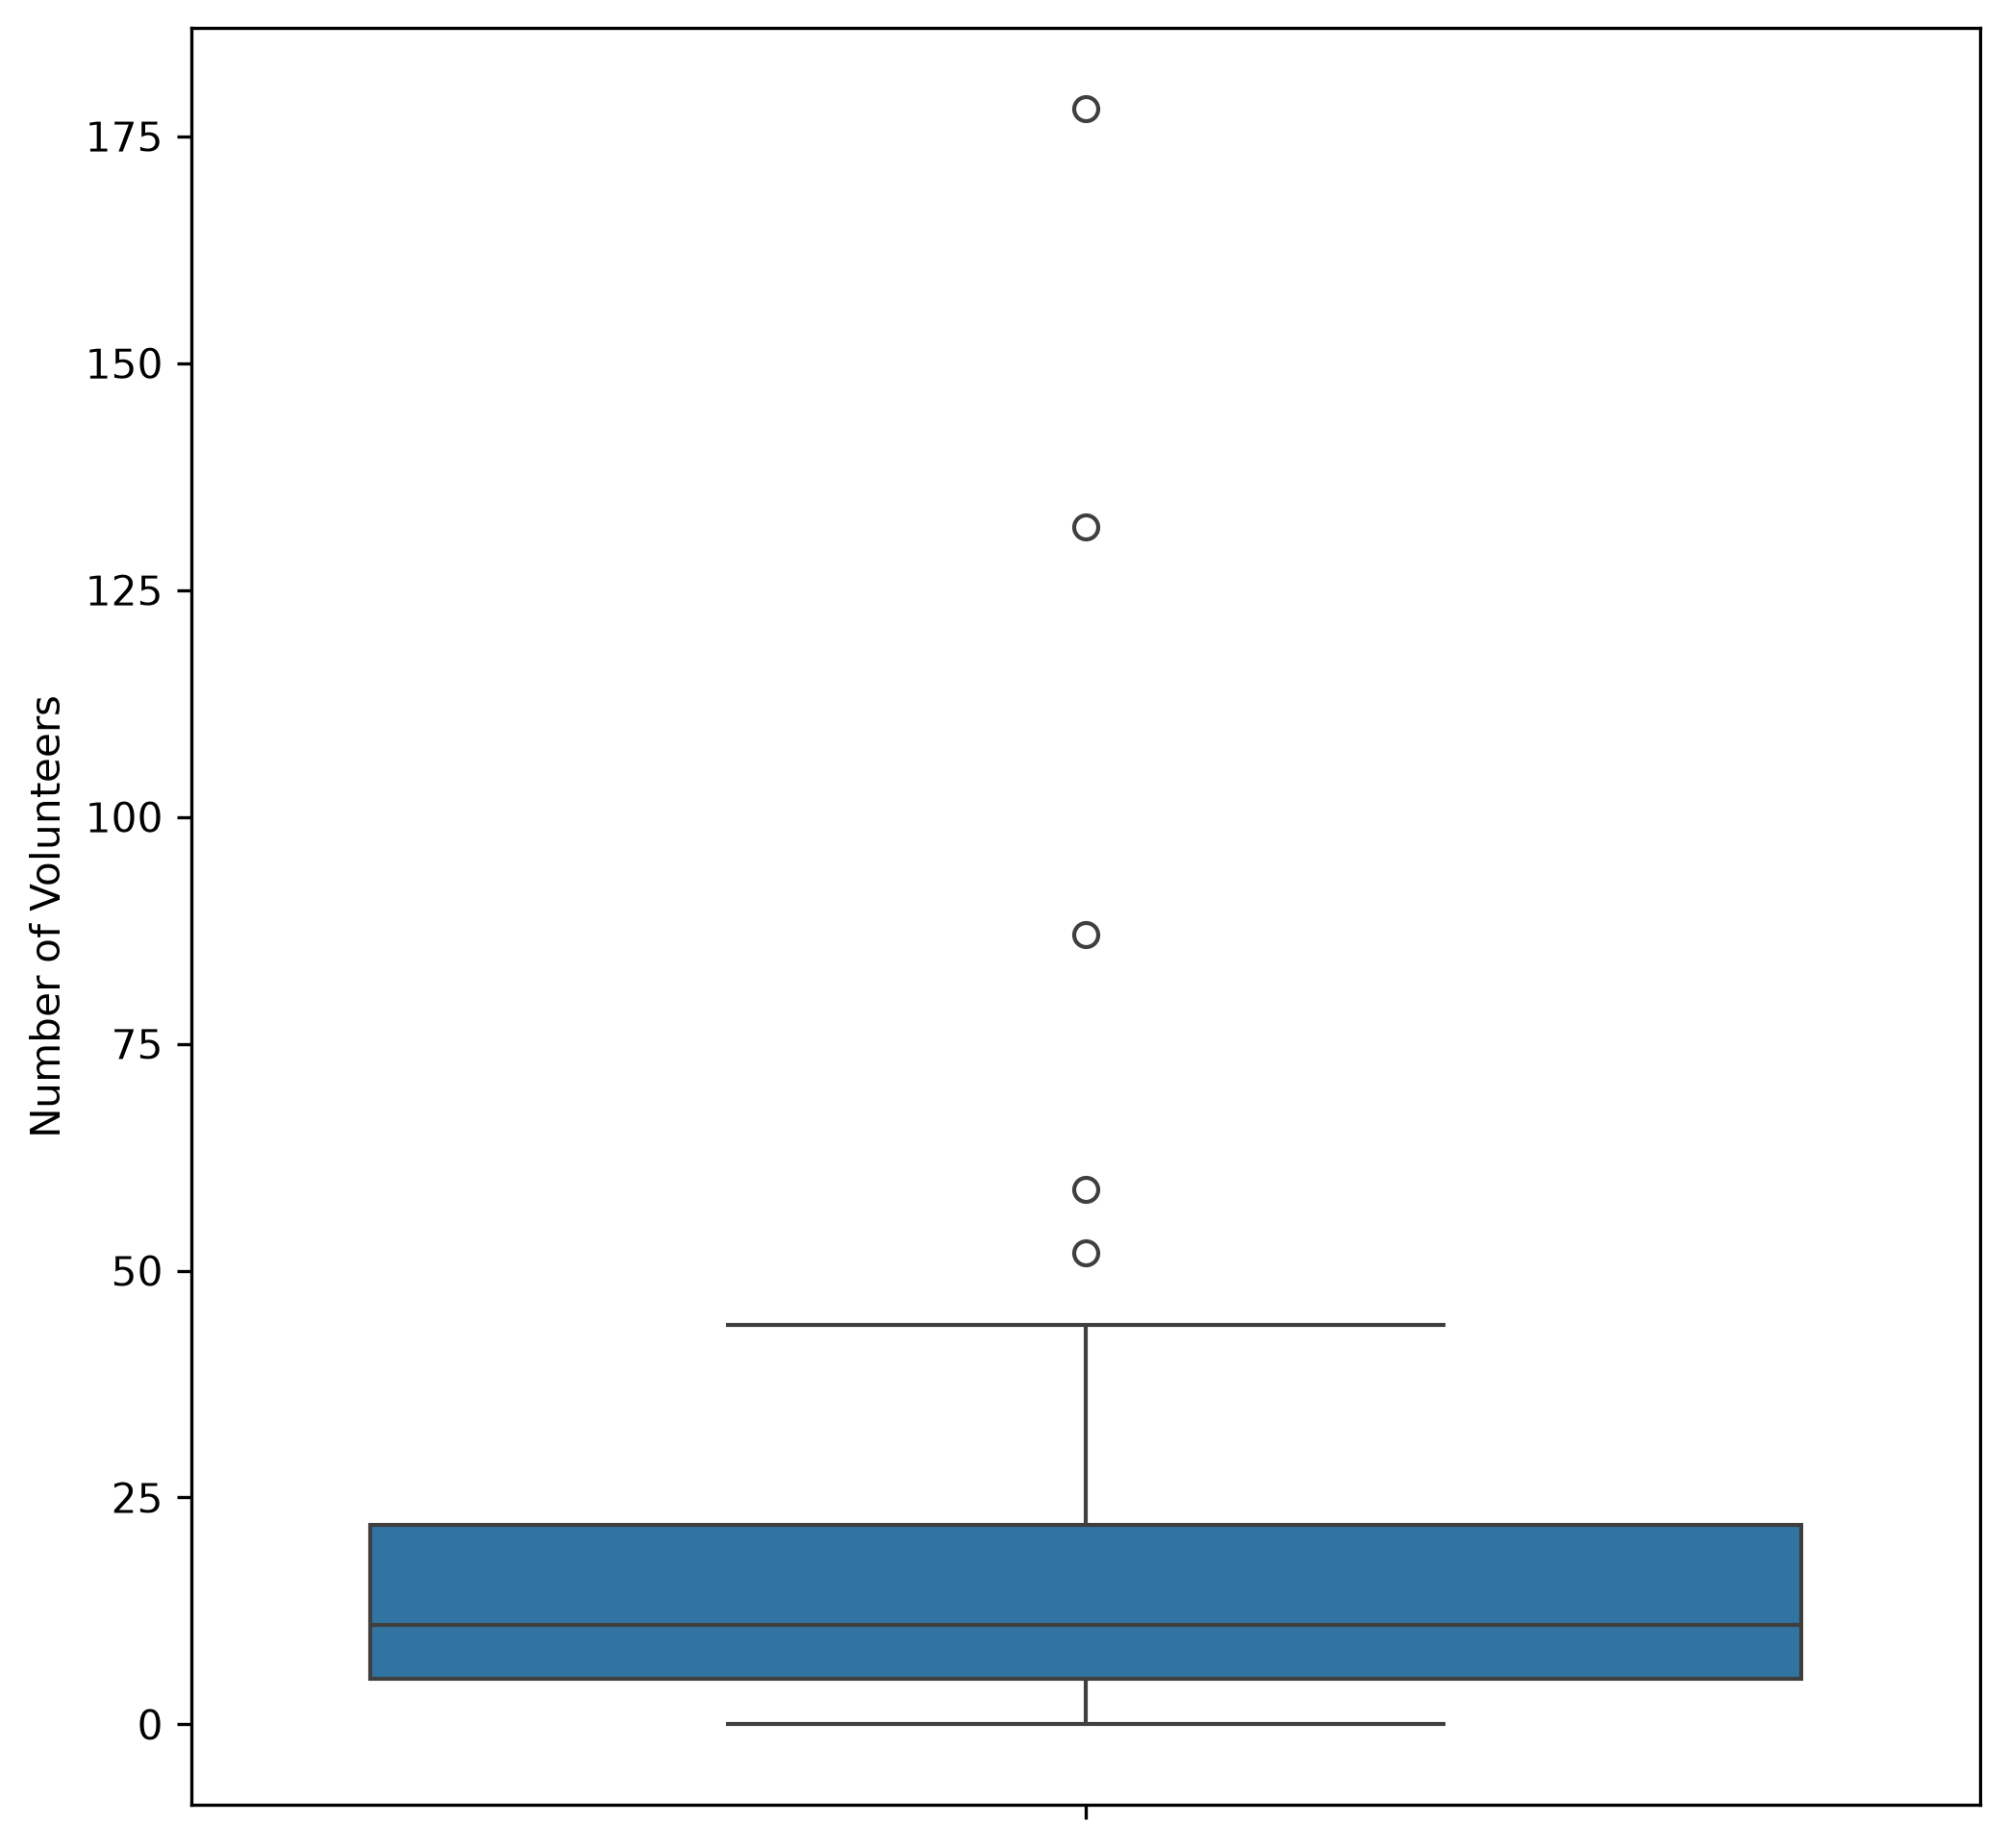

In [9]:
# boxplot of Number of Volunteers
fig, ax = plt.subplots(1, figsize=(8,8), dpi=300)
sns.boxplot(data=data, y='Number of Volunteers')

###
The boxplot shows that most observations have a relatively low number of volunteers. Several observations have much higher values and appear as potential outliers.

#### Comparison Across Cleanup Areas

To compare the amount of litter collected across cleanup areas, I will first convert Total Items Collected to a numeric variable so that it can be used for calculations. I will then look at the unique areas in the dataset to understand the different cleanup locations. Finally, I will identify the five areas with the highest total number of items collected and use a bar chart to compare them.

In [10]:
# convert Total Items Collected to numeric
data['Total Items Collected'] = pd.to_numeric(
    data['Total Items Collected'].str.replace(',', '')
)

In [11]:
# Look at unique areas
data.Area.unique()

<StringArray>
[                                                  'Ocean View Beach Park',
                                                           'Lakewood Park',
                                                         'Plum Point Park',
                                    'Lafayette Park & Lavalette Boat Ramp',
                                                            'Barraud Park',
                        'The Academy Of International Studies At Rosemont',
                                                       'Harbor Park (ERT)',
                                                         'Ocean View Park',
                                     'East Ocean View (1300 - 1900 Block)',
                               'Bayview Elementary/East Bayview Boulevard',
                                                      'ODU/Lamberts Point',
                                              'East Ocean View Rec Center',
                                                         'East Ocean View'

In [12]:
# Check datatype
data['Total Items Collected'].dtype 

dtype('float64')

In [13]:
# Find areas with the highest Total Items Collected
data.groupby('Area')['Total Items Collected'].sum().sort_values(ascending=False).head()

Area
Barraud Park                                    66041.5
Harbor Park (ERT)                               15528.0
Ocean View Beach Park                           13876.0
Willoughby Spit                                  8729.0
Lambert's Point (ODU Service Learning Group)     7892.0
Name: Total Items Collected, dtype: float64

In [14]:
# Select the top five areas
top_areas = ['Barraud Park',
             'Harbor Park (ERT)',
             'Ocean View Beach Park',
             'Willoughby Spit',
             "Lambert's Point (ODU Service Learning Group)"]

top = data[data['Area'].isin(top_areas)] 

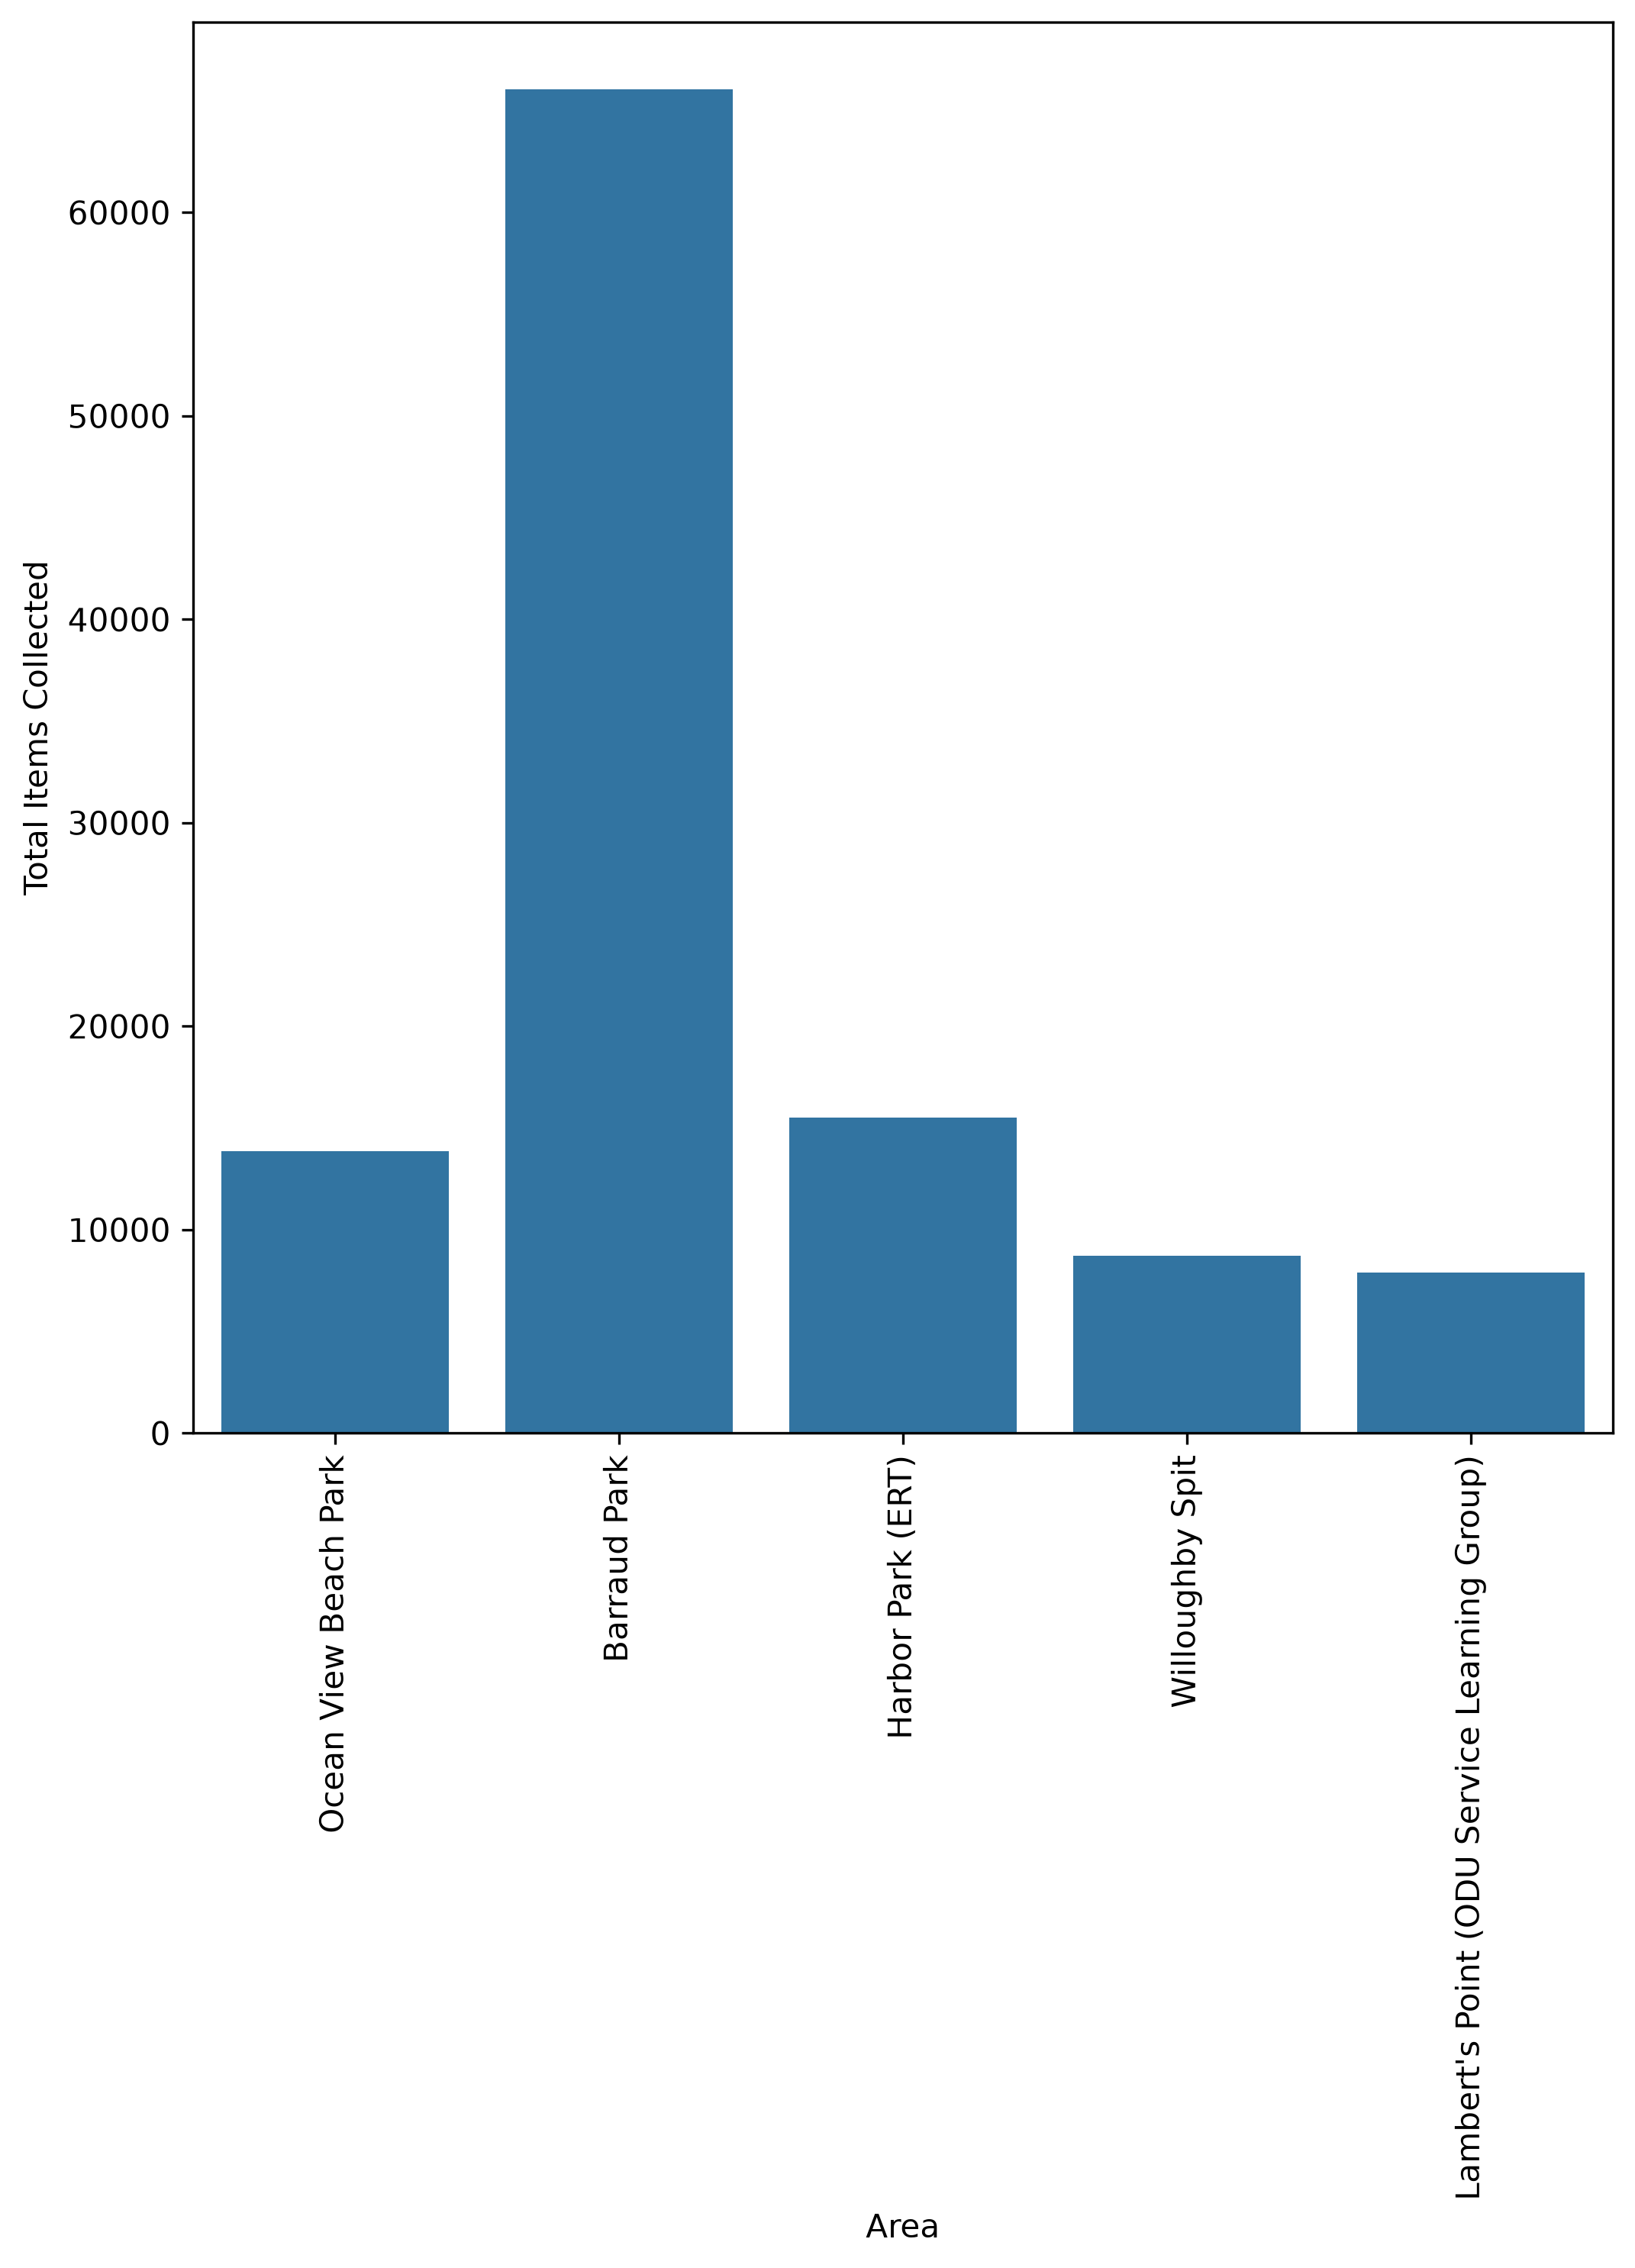

In [15]:
# Make a barplot of Total Items Collected by Area
fig, ax = plt.subplots(1, figsize=(8,8), dpi=300)
sns.barplot(data=top, x='Area', y='Total Items Collected', estimator=sum, errorbar=None)
plt.xticks(rotation=90)
plt.show() 

###
The bar chart shows that Barraud Park had the highest total number of items collected among the areas in the dataset. Harbor Park (ERT) and Ocean View Beach Park had the next highest totals. This shows that the amount of items collected varied considerably across cleanup areas.

#### Relationship Between Variables
To examine relationships among the numeric variables, I will first look at the correlation matrix. I will then focus on the relationship between the number of volunteers and the total number of items collected.

In [16]:
# correlations between the different numeric data columns in the dataframe
data.corr(numeric_only = True) 

,Take Out/Away Containers (Plastic),Take Out/Away Containers (Foam),Bottle Caps (Plastic),Lids (Plastic),"Straws, Stirrers","Forks, Knives, Spoons",Beverage Bottles (Plastic),Beverage Cans,Grocery Bags (Plastic),Other Plastic Bags,...,Other Trash (Clean Swell),Condoms,Diapers,Syringes,Tampons/Tampon Applicators,Foam Pieces,Total Items Collected,Number of Volunteers,Volunteer Hours,Number of Miles
Take Out/Away Containers (Plastic),1.000000,0.607496,0.356321,0.700904,0.507858,0.370703,0.668326,0.601108,0.545280,0.410773,...,0.271189,0.185698,0.167516,0.066776,0.375363,0.447907,0.404370,0.422706,0.388223,0.318016
Take Out/Away Containers (Foam),0.607496,1.000000,0.522715,0.702081,0.426763,0.413820,0.826804,0.790598,0.838231,0.809596,...,0.117206,0.342349,0.207407,0.289366,0.260685,0.648022,0.635792,0.611088,0.699840,0.169156
Bottle Caps (Plastic),0.356321,0.522715,1.000000,0.471438,0.763219,0.714716,0.541608,0.502784,0.510702,0.552785,...,0.020179,0.390141,0.330900,0.052537,0.201953,0.465964,0.792166,0.590190,0.629001,0.137659
Lids (Plastic),0.700904,0.702081,0.471438,1.000000,0.652222,0.592959,0.773948,0.751959,0.673629,0.610631,...,0.389840,0.309405,0.325772,0.102454,0.416994,0.441191,0.531248,0.656978,0.630329,0.347066
"Straws, Stirrers",0.507858,0.426763,0.763219,0.652222,1.000000,0.817765,0.630540,0.558492,0.541249,0.449572,...,0.186415,0.326327,0.401682,0.012366,0.286742,0.407406,0.706259,0.569830,0.528043,0.310443
"Forks, Knives, Spoons",0.370703,0.413820,0.714716,0.592959,0.817765,1.000000,0.496002,0.450093,0.427455,0.393730,...,0.049110,0.436123,0.580090,0.077531,0.267432,0.308287,0.646199,0.535732,0.541330,0.215445
Beverage Bottles (Plastic),0.668326,0.826804,0.541608,0.773948,0.630540,0.496002,1.000000,0.800585,0.863593,0.778327,...,0.093945,0.311348,0.171693,0.073737,0.308977,0.614354,0.623641,0.578888,0.614347,0.216427
Beverage Cans,0.601108,0.790598,0.502784,0.751959,0.558492,0.450093,0.800585,1.000000,0.800666,0.755259,...,0.286684,0.243859,0.188214,0.071944,0.349267,0.650321,0.689743,0.722856,0.713247,0.369462
Grocery Bags (Plastic),0.545280,0.838231,0.510702,0.673629,0.541249,0.427455,0.863593,0.800666,1.000000,0.822977,...,0.089429,0.215748,0.168951,0.061868,0.140619,0.716160,0.677283,0.531790,0.620355,0.199522
Other Plastic Bags,0.410773,0.809596,0.552785,0.610631,0.449572,0.393730,0.778327,0.755259,0.822977,1.000000,...,0.002415,0.327119,0.200830,0.028650,0.172072,0.689609,0.797830,0.671558,0.804402,0.091636


In [17]:
# correlation between Number of Volunteers and Total Items Collected
data[['Number of Volunteers', 'Total Items Collected']].corr() 

,Number of Volunteers,Total Items Collected
Number of Volunteers,1.00000,0.73076
Total Items Collected,0.73076,1.00000



The correlation between Number of Volunteers and Total Items Collected is approximately 0.73. This suggests a fairly strong positive relationship between the two variables. Cleanup observations with more volunteers tend to have more items collected.

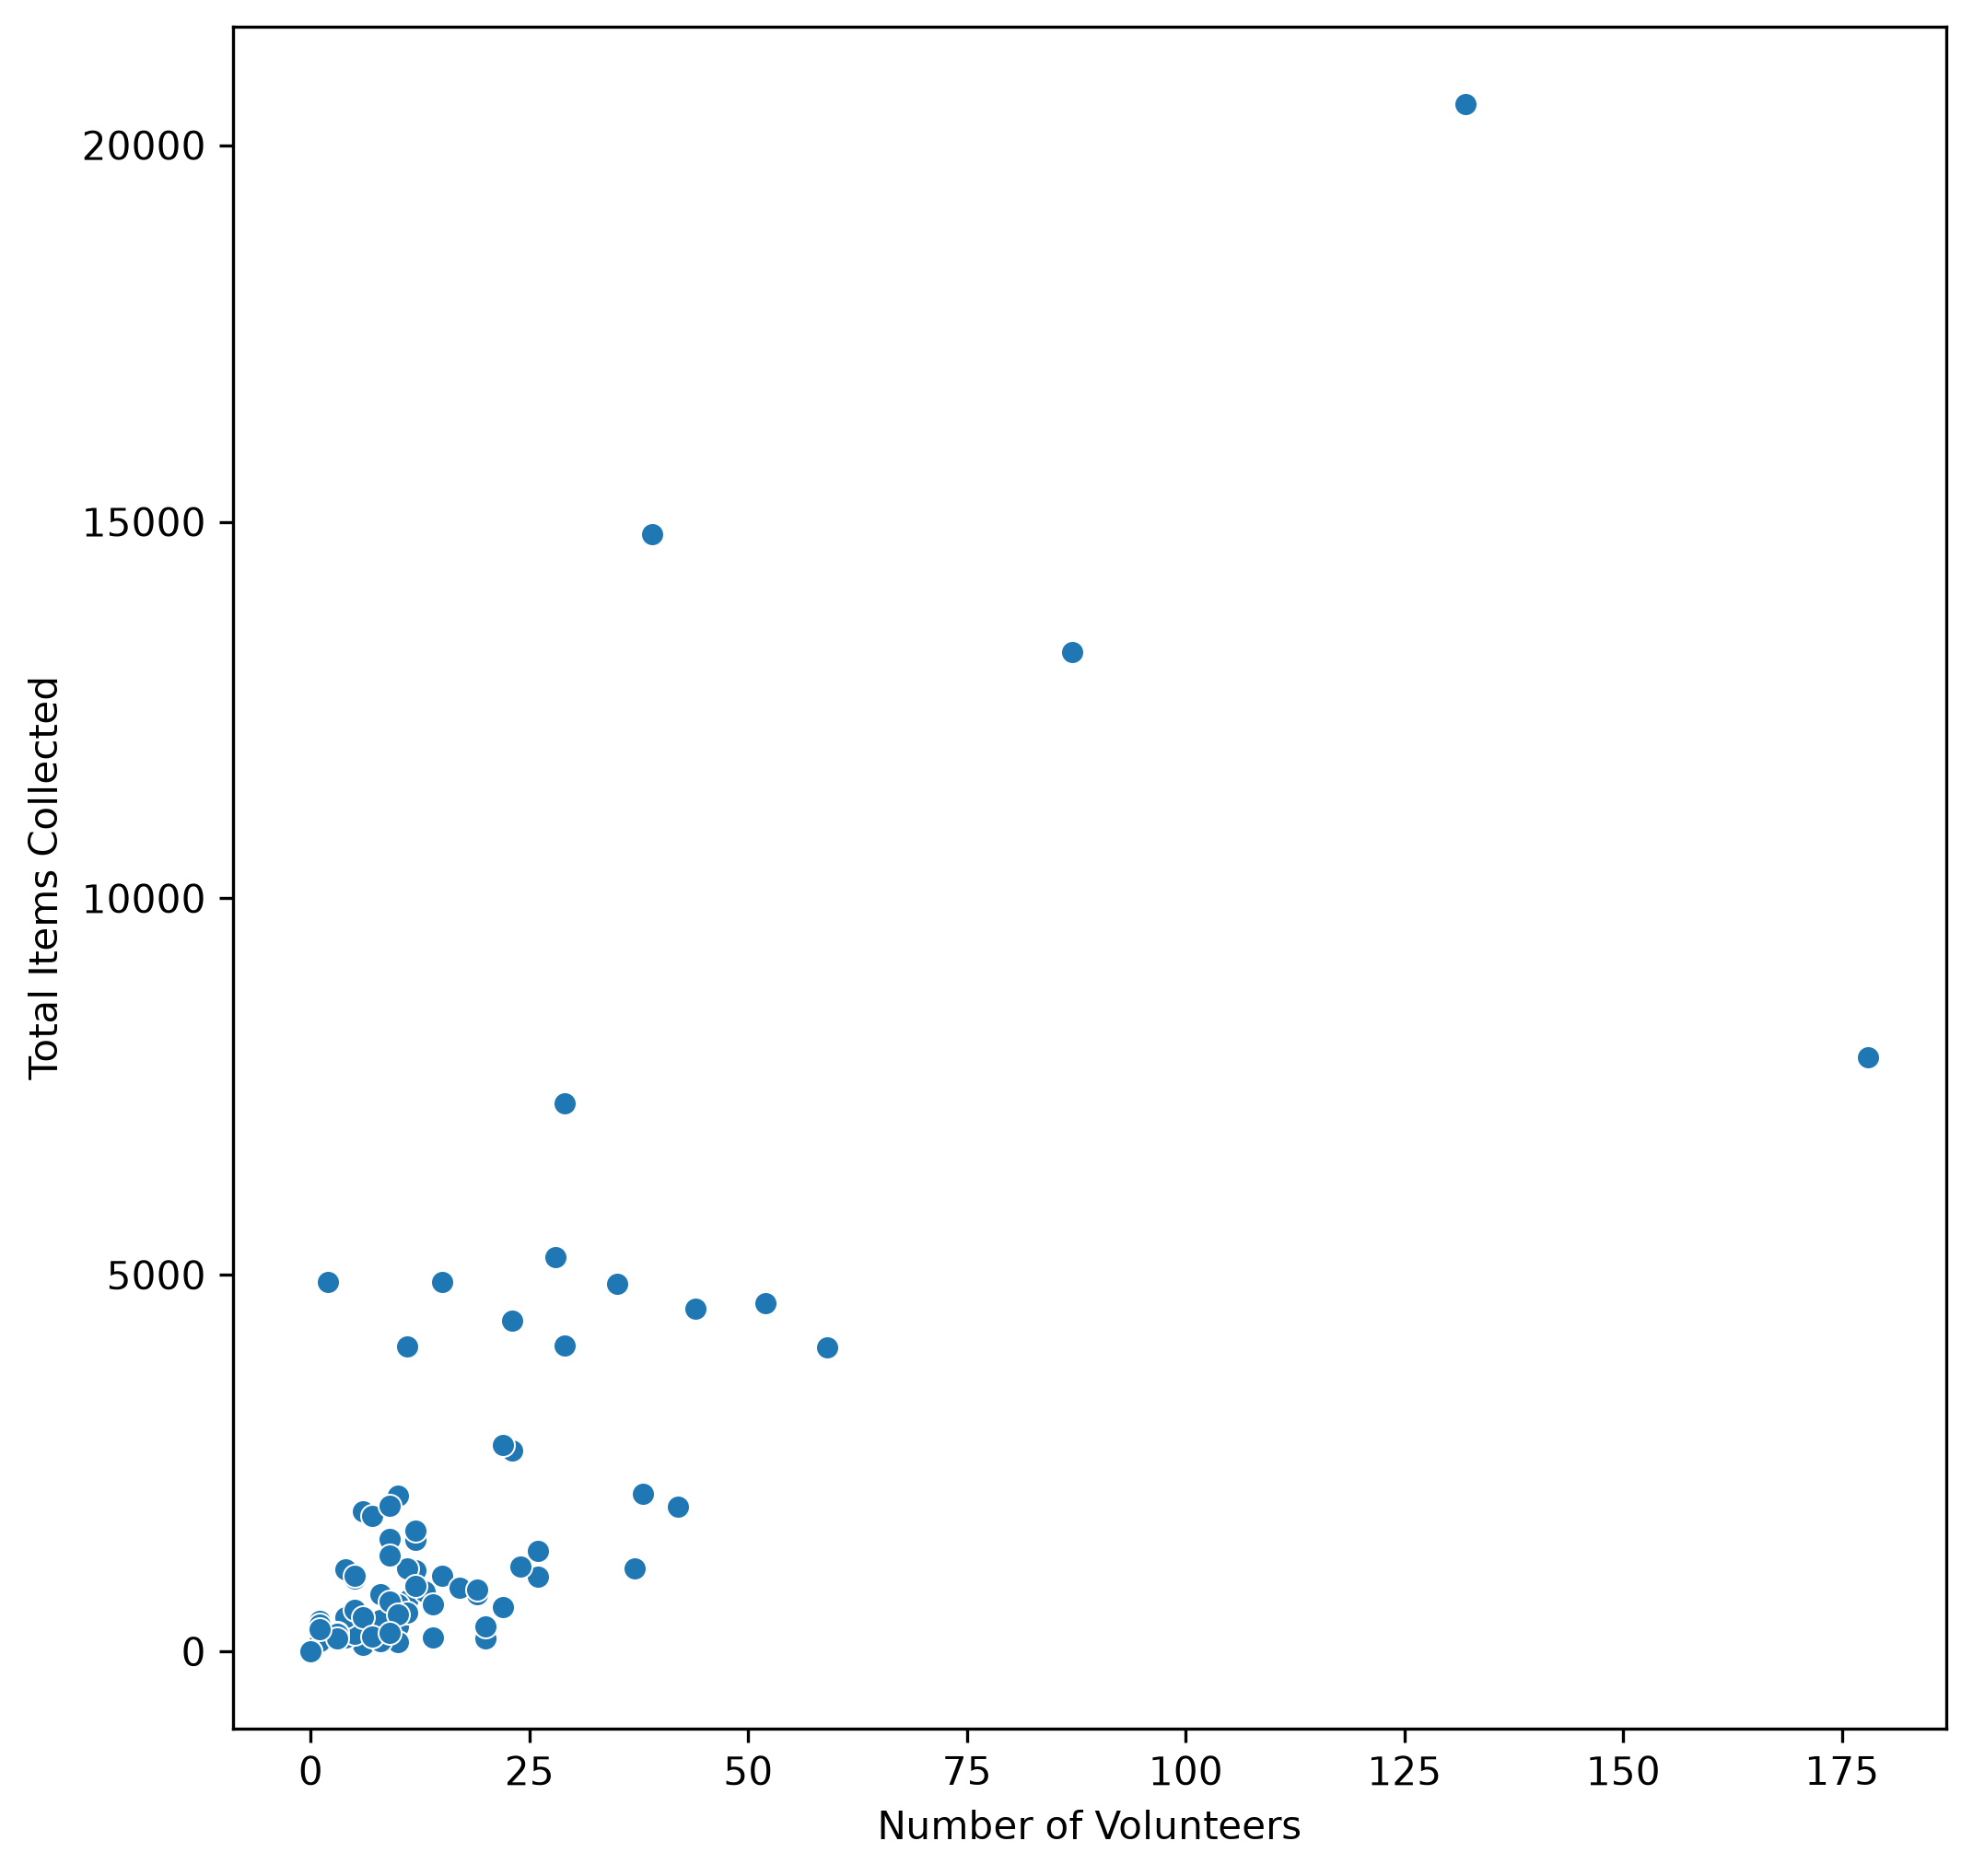

In [18]:
# scatter plot of Number of Volunteers and Total Items Collected
fig, ax = plt.subplots(1, figsize=(8,8), dpi=300)
sns.scatterplot(data=data, x='Number of Volunteers', y='Total Items Collected')
plt.show() 

###
The scatter plot shows a positive relationship between Number of Volunteers and Total Items Collected, which is consistent with the correlation of about 0.73. Most observations have fewer volunteers and fewer items collected, while a few observations have much higher values. There are also some possible outliers, especially the observation with around 180 volunteers.

#### Initial Conclusions

The EDA shows that the cleanup dataset contains considerable variation across observations. Most cleanup events had a relatively small number of volunteers, while a few events had much larger numbers of volunteers. Some variables also contained unusually high values, which may represent larger cleanup events rather than data errors.

There is a positive relationship between Number of Volunteers and Total Items Collected. The correlation is approximately 0.73, and the scatter plot also shows that events with more volunteers generally collected more items. The analysis also shows differences across cleanup areas, with some areas having much higher total numbers of items collected than others.

Overall, the EDA helped identify the main patterns, variation, and possible outliers in the dataset.